In [2]:
#Load Dataset
import pandas as pd

# Load dataset
df = pd.read_csv("../data/creditcard.csv")

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#Check number of rows and columns
df.shape
print("Number of rows: ",df.shape[0])
print("Number of columns: ",df.shape[1])

Number of rows:  284807
Number of columns:  31


In [4]:
#check if duplicate value is available
df.isnull().sum().any()

np.False_

In [5]:
#check class distribution
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [7]:
#Identify Imbalance Problem
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

print("Fraud Transactions:", len(fraud))
print("Normal Transactions:", len(normal))

print("Fraud Percentage:", len(fraud)/len(df) * 100)

Fraud Transactions: 492
Normal Transactions: 284315
Fraud Percentage: 0.1727485630620034


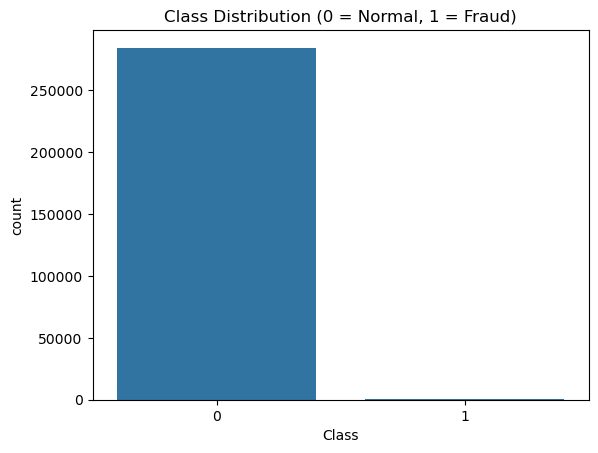

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Normal, 1 = Fraud)")
plt.show()

The dataset contains 284,807 transactions.
Fraud transactions account for only 0.17% of the total data.
This indicates a severe class imbalance problem.
Therefore, evaluation metrics like Precision, Recall, and F1-score will be more appropriate than Accuracy.

In [9]:
## Phase 2: Data Preprocessing
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

# Remove duplicates
df = df.drop_duplicates()

# Verify again
print("Duplicate rows after removal:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows: 1081
Duplicate rows after removal: 0
New dataset shape: (283726, 31)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


In [11]:
df = df.drop("Time", axis=1)

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0


In [13]:
df.columns
X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (283726, 29)
Target shape: (283726,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (226980, 29)
Testing set shape: (56746, 29)


In [15]:
print("Training distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training distribution:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing distribution:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


### Data Preprocessing Summary

In this phase:
- Duplicate records were removed
- The "Amount" feature was scaled using StandardScaler
- The "Time" column was dropped as it is less relevant
- Data was split into features (X) and target variable (y)
- A stratified train-test split was applied to maintain fraud class distribution

The dataset is now ready for model training.

## Phase 3: Exploratory Data Analysis (EDA)

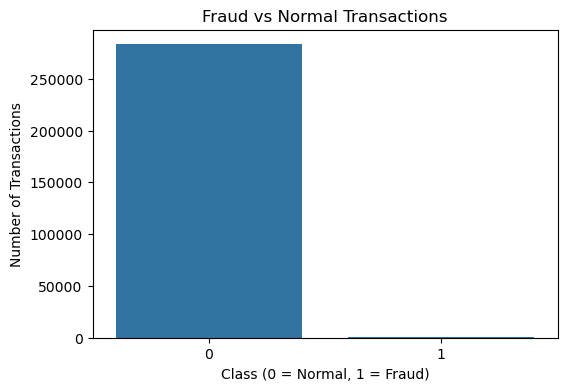

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

Fraud transactions are extremely rare compared to normal transactions.
This confirms that the dataset is highly imbalanced.

In [17]:
fraud_percentage = (df["Class"].value_counts(normalize=True) * 100)

print(fraud_percentage)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


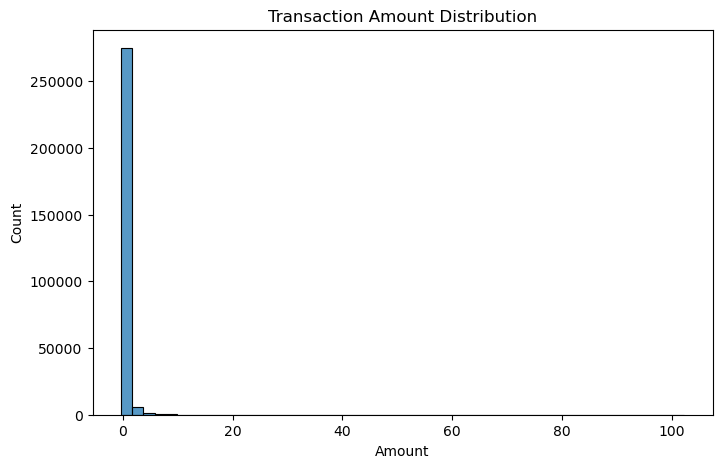

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

Most transactions are small amounts, with very few large transactions.

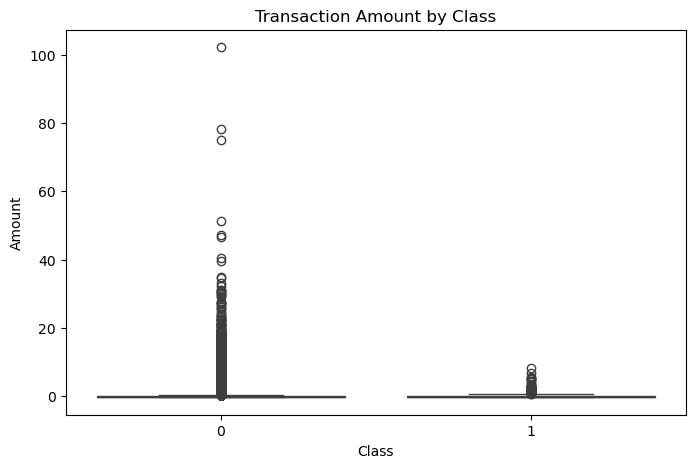

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")

plt.show()

Fraudulent transactions show different amount patterns compared to normal transactions.

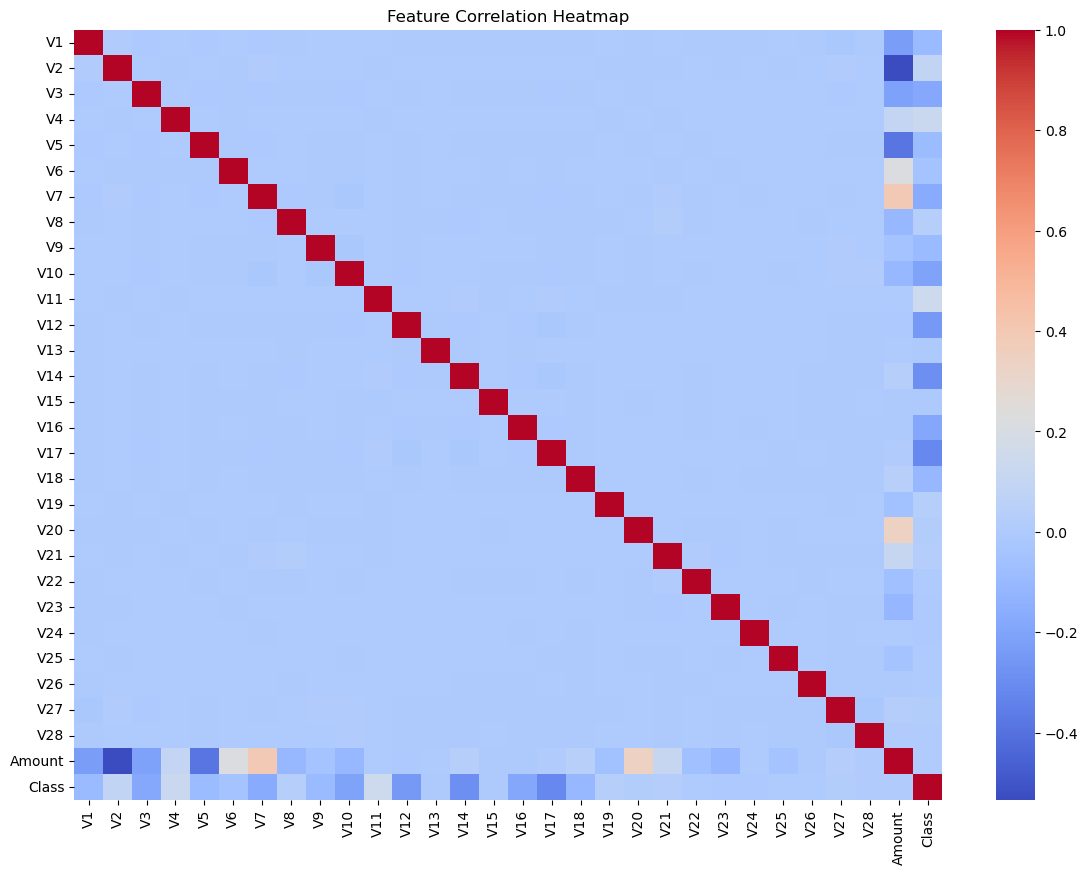

In [20]:
plt.figure(figsize=(14,10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

In [21]:
fraud_corr = df.corr()["Class"].sort_values(ascending=False)

print(fraud_corr.head(10))

Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64


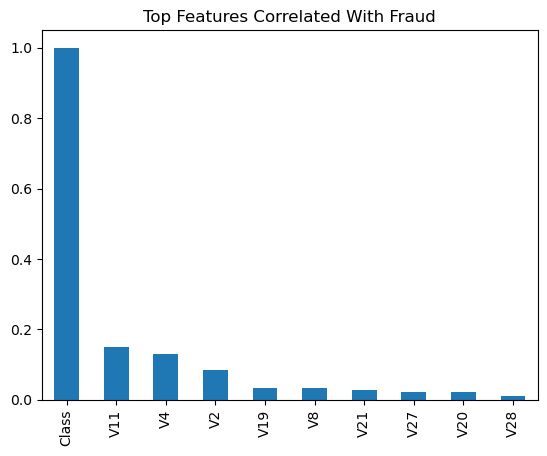

In [22]:
fraud_corr.head(10).plot(kind="bar")

plt.title("Top Features Correlated With Fraud")

plt.show()

### EDA Insights

Key observations from the dataset:

- Fraud transactions are extremely rare (~0.17%).
- The dataset is highly imbalanced.
- Transaction amounts are mostly small values.
- Some PCA features show stronger correlation with fraud cases.

These insights highlight the need for careful model evaluation using precision and recall rather than relying solely on accuracy.

In [23]:
## Phase 4: Model Training


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [25]:
# Initialize model
logistic_model = LogisticRegression(max_iter=1000)

# Train model
logistic_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [26]:
y_pred_logistic = logistic_model.predict(X_test)

In [27]:
# Initialize Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)

# Train model
tree_model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [28]:
y_pred_tree = tree_model.predict(X_test)

## Phase 5: Model Evaluation

In [29]:
from sklearn.metrics import confusion_matrix, classification_report

In [30]:
print("Logistic Regression Results")

print(confusion_matrix(y_test, y_pred_logistic))

print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
[[56641    10]
 [   38    57]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.60      0.70        95

    accuracy                           1.00     56746
   macro avg       0.93      0.80      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [31]:
print("Decision Tree Results")

print(confusion_matrix(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

Decision Tree Results
[[56625    26]
 [   30    65]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.71      0.68      0.70        95

    accuracy                           1.00     56746
   macro avg       0.86      0.84      0.85     56746
weighted avg       1.00      1.00      1.00     56746



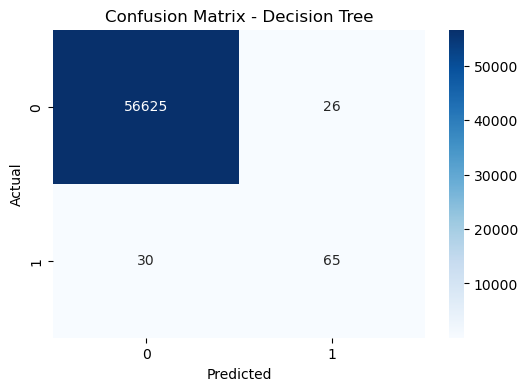

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Model Evaluation Summary

Both Logistic Regression and Decision Tree models were trained to detect fraudulent transactions.

Due to the highly imbalanced dataset, accuracy alone is not a reliable metric.

Instead, precision and recall were used to evaluate model performance.

Recall is particularly important in fraud detection because missing a fraudulent transaction can lead to financial loss.

In [33]:
## Phase 6: Model Performance Visualization

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

In [35]:
y_prob = logistic_model.predict_proba(X_test)[:,1]

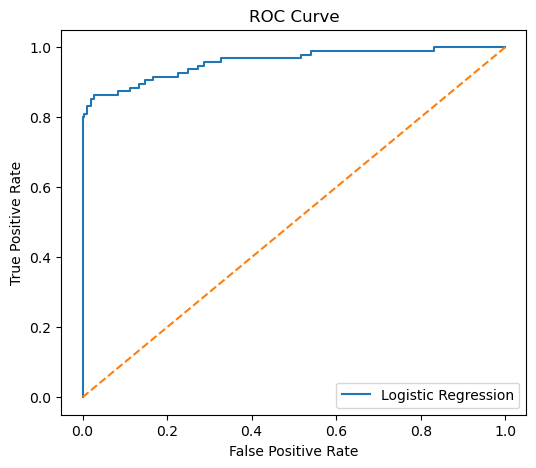

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC curve shows the trade-off between True Positive Rate and False Positive Rate.

A higher AUC value indicates better model performance.

In [37]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X_train.columns
)

top_features = feature_importance.sort_values(ascending=False).head(10)

top_features

V17    0.532432
V14    0.093275
V10    0.083939
V26    0.041204
V21    0.022498
V6     0.021857
V7     0.020690
V16    0.020331
V1     0.017983
V4     0.017443
dtype: float64

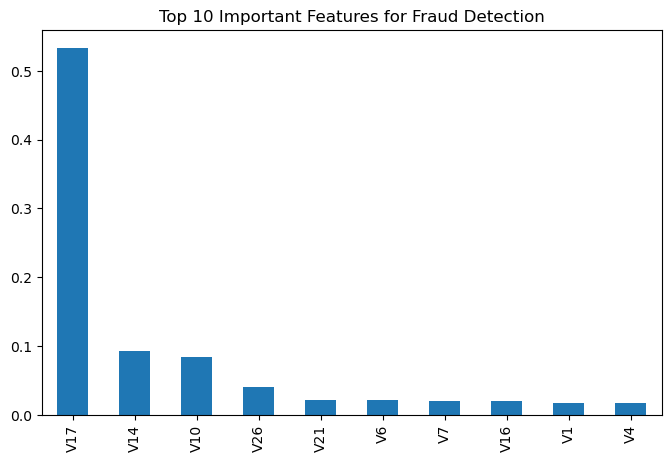

In [38]:
plt.figure(figsize=(8,5))

top_features.plot(kind="bar")

plt.title("Top 10 Important Features for Fraud Detection")

plt.show()

Decision Tree models provide feature importance scores that indicate
which variables contribute most to fraud prediction.

In [40]:
import pickle

In [41]:
with open("../outputs/fraud_model.pkl", "wb") as file:
    pickle.dump(logistic_model, file)

In [42]:
with open("../outputs/fraud_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

## Project Conclusion

In this project, we built a machine learning pipeline to detect
fraudulent credit card transactions.

Steps completed:

- Data understanding and exploration
- Data preprocessing
- Exploratory data analysis
- Training Logistic Regression and Decision Tree models
- Model evaluation using precision, recall, and F1-score
- Visualization using ROC curve
- Feature importance analysis
- Model saving for future deployment

Key Insight:
The dataset is highly imbalanced, so recall is an important metric
for fraud detection.

Future Improvements:
- Handle imbalance using SMOTE
- Try advanced models like Random Forest or XGBoost
- Deploy model using Streamlit